In [43]:
using Revise
using Statistics

using Pkg; Pkg.activate(".")

using PythonPlot
using JLD2
using CSV
using DataFrames
using NCDatasets
using Printf
using DSP

include("./read_lidar.jl")
using .read_lidar
using .read_lidar.stare
using .read_vecnav: read_vecnav_dict
import .chunks
read_stare_time  = Main.chunks.read_stare_time
read_stare_chunk = Main.chunks.read_stare_chunk
fit_offset = Main.chunks.fit_offset

include("./timing_lidar.jl")
using .timing_lidar

pd = permutedims

  Activating project at `~/Projects/lidar/ASTRAL2024`


permutedims (generic function with 25 methods)

In [2]:
# load lidar timing and indexing data

# ic         all lidar chunk indices
# dtime_st   lidar chunk start times
# icvn       chunk indices with Vn data

# load:

FileInds = load("file_beam_inds.jld2")
bigind_file_ends   = FileInds["bigind_file_end"] # 991, one per file
bigind_file_starts = FileInds["bigind_file_start"]

LidarDt = load("lidar_dt.jld2")
iens               = LidarDt[ "ien"            ] # 5938 chunk start indices
ists               = LidarDt[ "ist"            ] #            end
# LidarDt["dtime"] # 3174132, one per second
dtime_st = LidarDt["dtime"][ists]
dtime_en = LidarDt["dtime"][iens]
ic = eachindex(iens)

Vn = read_vecnav_dict()
icvn = findfirst( dtime_st .>= Vn[:vndt][1] ):findlast( dtime_en .<= Vn[:vndt][end] )

# sync offset and quality data
synclog = CSV.read("data/vn_sync_chunk_daily/all_sync_log_mdv_vn2.csv", DataFrame)

Row,ic,day,offset_1hz_s,offset_total_s,corr,vn_coverage,n_beams,nan_frac_vn2,status
,Int64,Date,Float64,Float64,Float64,Float64,Int64,Float64,String15
1,175,2024-04-29,-1.02,-0.62,0.4472,0.9922,537,0.0,ok
2,176,2024-04-29,-1.02,-0.62,0.5398,0.9935,537,0.0,ok
3,177,2024-04-29,-1.02,-0.67,0.7065,0.9934,518,0.0,ok
4,178,2024-04-29,-1.02,-0.57,0.4981,0.9928,537,0.0,ok
5,179,2024-04-29,-1.02,-0.62,0.8406,0.9915,537,0.0,ok
6,180,2024-04-29,-1.02,-0.67,0.4624,0.993,537,0.0,ok
7,181,2024-04-29,-1.02,-0.57,0.5598,0.9931,537,0.0,ok
8,182,2024-04-29,-1.02,-0.57,0.6904,0.9932,537,0.0,ok
9,183,2024-04-29,0.0,-0.5,0.5576,0.9919,518,0.0,ok


## Sign convention of `offset_total_s` (s)

```pseudocode
vn2_aligned[t] = vn2[t − offset_total_s] ≈ mdv[t]
```
VN timestamps are ~+0.85 s BEHIND lidar timestamps. VN data from EARLIER times need to be shifted up to align with the lidar.

The sign is defined by shift_signal_linear (line 469):

VN2 is shifted with final_offset to match mdv, so after shifting: vn2_shifted[t] = vn2[t − offset_total_s] ≈ mdv[t].

The lag equation is:
```
Vn2[t-δ] ≈ mdv[t]
δ = offset_total_s
```

Typical values are `offset_total_s` ≈ −0.85 s, so:
`Vn2[t+0.85s]≈mdv[t]`
meaning the VN clock lags the lidar clock by ~0.85 s — VN timestamps are about 0.85 s behind

"offset>0 <==> VN clock lags; synced by sampling VN earlier"

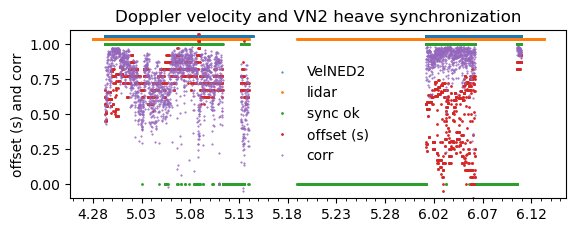

In [18]:
# plot an overview of sync performance

sync_ok = synclog[:, :status] .== "ok"
ic_ok = synclog[:, :ic][sync_ok]

#offset_total_s	corr	vn_coverage
fltm(x; missingval=-9999.0) = ( isapprox(x, missingval) ? NaN : x )

clf()
subplot(2,1,1)
# plot(dtime_st[icvn], 1.04 .+zeros(size(icvn)), marker=".", markersize=2, linestyle="none", label="chunks w/ VN")
plot(Vn[:vndt][1:20*60*3:end],  1.06 .+ 0*Vn[:VelNED2][1:20*60*3:end], marker=".", markersize=1, linestyle="none", label="VelNED2")
plot(dtime_st[ic],  1.04 .+zeros(size(ic)),   marker=".", markersize=2, linestyle="none", label="lidar")

plot(dtime_st[synclog[:, :ic]],  sync_ok, marker=".", markersize=2, linestyle="none", label="sync ok")

plot(dtime_st[synclog[:, :ic]], -fltm.(synclog[:, :offset_total_s]), marker=".", markersize=2, linestyle="none", label="offset (s)")
plot(dtime_st[synclog[:, :ic]],  fltm.(synclog[:, :corr]), marker=".", markersize=1, linestyle="none", label="corr")
ylim([-0.1, 1.1])
ylabel("offset (s) and corr")
legend(frameon=false)
ax = gca()
ax.xaxis.set_major_locator(PythonPlot.matplotlib.dates.DayLocator(interval=5))
ax.xaxis.set_minor_locator(PythonPlot.matplotlib.dates.DayLocator(interval=1))
ax.xaxis.set_major_formatter(PythonPlot.matplotlib.dates.DateFormatter("%-m.%d"))
# PythonPlot.matplotlib.pyplot.setp(ax.get_xticklabels(), rotation=60) #, ha="right")
title("Doppler velocity and VN2 heave synchronization")
display("offset>0 <==> VN clock lags; synced by sampling VN earlier")

for fmt in ["png", "pdf", "eps", "svg"][1:1]
    savefig("sync_availability.$(fmt)") # overview of sync performance
end
gcf()


While technically improved, lag of less than 1 s explains why no offset refinement was needed to sync timeseries. The prior lag offset I provided before was close and worked. Now we have additional refinement, and confidence that that refinement was small.

In [148]:
# load a day that's well synced

# syncday = Dataset("data/vn_sync_chunk_daily/mdv_vn2_sync_20240506.nc")
iday = findall(in(ic_ok), syncday[:chunk_ic][:]) # synced chunk index within day
icdayok = syncday[:chunk_ic][iday] # synced chunk universal indices
start_ok = syncday[:time_start_idx][iday]
end_ok = syncday[:time_end_idx][iday]
i=11
#for i in iday[1:1]
    vn2_aligned = syncday[:vn2_aligned][start_ok[i]:end_ok[i]]
    mdv = syncday[:mdv][start_ok[i]:end_ok[i]]
#end

X = hcat(Float64.(mdv), Float64.(vn2_aligned))

539×2 Matrix{Float64}:
 -0.1911  -0.146886
 -0.344   -0.306543
 -0.1147  -0.137424
 -0.1529  -0.139361
 -0.344   -0.453282
 -0.6498  -0.75127
 -0.5733  -0.732059
 -0.3822  -0.536271
 -0.2294  -0.380309
 -0.0765  -0.079906
  ⋮       
 -0.0383  -0.29649
 -0.3822  -0.65873
 -0.4205  -0.609721
 -0.1147  -0.325503
 -0.0765  -0.243717
 -0.0383  -0.237866
  0.0764   0.0206013
  0.4204   0.378828
  0.535    0.628344

In [ ]:
# calculate cross spectrum

fs = 1/1.02           # Sampling frequency 1/s

# Compute Cross Spectrum (CSD)
# Passing (x, y) computes the cross-periodogram
nt = size(X,1)
# mt_config = MTSpectrogramConfig(nt, 128, 64; fs=fs)
csd = mt_cross_power_spectra(pd(X); nfft=1024, fs=fs)
# Extract frequency and complex spectral power
freqs = freq(csd) * fs
P = power(csd)  # Complex cross-spectral density
p_xy = P[1,2,:]
p_xx = P[1,1,:] # mdv
p_yy = P[2,2,:] # vn2_aligned
coh = abs.(p_xy).^2 ./ (p_xx .* p_yy) # coherency^2

513-element Vector{ComplexF64}:
  0.003420672662703778 - 0.0im
  0.017752560568311957 + 2.262882567974001e-19im
  0.010174065022707592 + 5.545165767833936e-20im
   0.05182275291456232 + 7.633805687593459e-19im
   0.03206149263547707 - 1.73256523353681e-20im
  0.014175225122021165 + 1.651954506398964e-19im
   0.01721436225404895 - 8.686882414660721e-20im
  0.013149048340841057 + 2.440630037790356e-19im
   0.01950670894538066 + 1.7884829939705043e-19im
 0.0012134658691728948 + 3.521331231995944e-21im
                       ⋮
   0.25035463460325375 + 1.0113502466969441e-18im
   0.03621139999819462 + 3.4865434958314565e-19im
   0.28291252241504916 - 2.1782587036474086e-18im
   0.33118415696758857 - 2.7967652128500334e-17im
   0.29332947209915067 + 8.611939158230624e-18im
   0.10983752052860851 - 1.3791950703624595e-18im
   0.14324425131058938 - 3.597134782977028e-18im
    0.0228520363346802 - 2.1538448415661104e-19im
   0.13572450192124502 - 0.0im

In [169]:
# bandpass filter for getting motion from coherent mdv

bflt = digitalfilter(Bandpass(0.062, 0.25), Butterworth(5); fs=fs)
# mdvfilt = filtfilt(bflt, Float64.(mdv))
w = freqs / fs * 2 * pi
bresp = freqresp(bflt, w)

# Design an FIR filter (returns coefficients 'b')
fflt = digitalfilter(Bandpass(0.045, 0.27), FIRWindow(hamming(91)); fs=fs)
mdvfilt = fftfilt(fflt, Float64.(mdv))
w = freqs / fs * 2 * pi
fresp = freqresp(PolynomialRatio(fflt, [1.0]), w)

csdf = mt_cross_power_spectra(
    pd(hcat(Float64.(mdvfilt), Float64.(vn2_aligned))); 
    nfft=1024, fs=fs)
Pf = power(csdf)
p_xxf = Pf[1,1,:]
p_yyf = Pf[2,2,:]
p_xyf = Pf[1,2,:]
cohf = abs.(p_xyf).^2 ./ (p_xxf .* p_yyf)


513-element Vector{ComplexF64}:
   0.1582763045334135 - 0.0im
 0.023177565708326204 - 4.580684358971357e-19im
  0.16426184418689407 + 7.467471915083029e-19im
 0.024606315683238112 - 7.143043414139019e-20im
  0.19111823331795774 - 1.6244469761108545e-18im
 0.027910848679293936 + 9.09537407699735e-19im
   0.2702017052641364 + 1.6315518653851355e-17im
   0.5400496776972078 + 6.295804244787366e-18im
   0.5951441461596038 + 2.2519259424604505e-18im
   0.7462684006493532 + 2.4628889368071803e-18im
                      ⋮
   0.6282631803456781 + 4.180880630943456e-18im
    0.747266869216273 + 7.099398879004366e-18im
   0.6301334271250246 - 1.14094852870586e-19im
   0.8043571206214848 - 1.1536062448111225e-16im
   0.8031605598545544 + 5.4052881228587496e-17im
    0.683955093901286 + 4.78095781146707e-19im
   0.6732957172678383 - 3.5244294425824426e-17im
   0.7736739568861846 + 1.082889040146978e-17im
   0.7035371476816561 - 0.0im

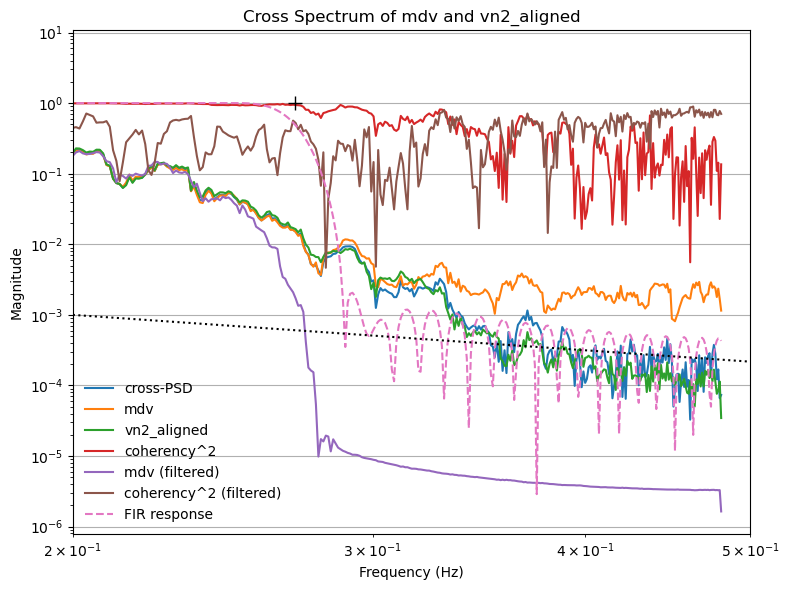

In [170]:
# plot cross-spectrum

fig, (ax1) = subplots(1, 1, sharex=true, figsize=(8, 6))

# Magnitude Plot
ax1.loglog(freqs, abs.(p_xy), label="cross-PSD")
ax1.plot(freqs, abs.(p_xx), label="mdv")
ax1.plot(freqs, abs.(p_yy), label="vn2_aligned")
ax1.plot(freqs, abs.(coh), label="coherency^2")

ax1.plot(freqs, abs.(p_xxf), label="mdv (filtered)")
ax1.plot(freqs, abs.(cohf), label="coherency^2 (filtered)")

ax1.plot([0.06, 0.27], [1, 1], "k+", markersize=10)
# ax1.plot(fs/(2*pi)*w, abs.(bresp), "--", label="Butterworth response")
ax1.plot(fs/(2*pi)*w, abs.(fresp), "--",label="FIR response")

ax1.plot([0.2, 0.5], 1e-3*([0.2, 0.5]/0.2).^(-5/3), "k:")
# ax1.plot(freqs, angle.(p_xy)/(2*pi), label="phase (cycles)")

ax1.legend(frameon=false)
ax1.set_ylabel("Magnitude")
ax1.set_xlabel("Frequency (Hz)")
ax1.set_xlim(0.2, 0.5)
ax1.grid(true)
ax1.set_title("Cross Spectrum of mdv and vn2_aligned")

tight_layout()
gcf()

In [54]:
# fractions of good data
length(icvn) / length(ic) # 0.91 of chunks have VN data
sum(sync_ok) / length(sync_ok) # 0.47 of chunks with VN have good sync
# VN data missing or unsynced May 18-June 1.

0.47431412262935

In [ ]:
# load VN heave aligned to one chunk's lidar times from daily sync NC
vn2_aligned = load_vn2_aligned(ic, ist, ien, LidarDt["dtime"])

In [1]:
Sys.getpid()

57242